# Discovering a linear causal signaling network from perturbation data

Perturbation experiments often measure continuous molecular responses: log-fold changes in phosphoproteins, reporter intensities, or expression signatures after stimulating or inhibiting a pathway component.

This guide starts from one question:

> **Which directed interactions in a prior-knowledge network are sufficient to explain the measured responses across observational and intervention conditions?**

`LinearDAGDiscovery` searches a directed prior-knowledge network (PKN) for a sparse, acyclic linear structural causal model. The same edge coefficients are shared across samples, while interventions change which structural equations are evaluated. Artificial network flows certify that selected edges lie on routes from interventions to measured responses.

The result is an experimentally supported linear pathway hypothesis. It is not proof that every omitted interaction is biologically absent, and the structural flows are not biochemical fluxes.

## When is this method useful?

| Experimental setting | Interpretation |
|---|---|
| Continuous molecular measurements | Values may be signed and need not be discretized |
| Several perturbation conditions | Perturbations help orient otherwise ambiguous associations |
| Directed PKN with alternatives or feedback | The selected model is a feed-forward subset of the candidate biology |
| One mechanism shared across samples | Edge coefficients do not change between conditions |

Use `CellNOptDAG` instead when the biological question is naturally Boolean—active versus inactive proteins, AND gates, and inhibitory logic. Use `LinearDAGDiscovery` when effect magnitude and sign are informative and an additive linear approximation is reasonable.

## Example: separating the AKT and ERK branches downstream of EGFR

Consider a small perturbation panel measuring five signaling activities. The biological hypothesis is that EGFR activates both AKT and ERK, AKT inhibits FOXO, and ERK activates ELK1.

The PKN is intentionally less certain. It also contains reverse interactions and AKT–ERK cross-talk that could form cycles. Our experiment should determine whether those alternatives are needed.

The values below can be read as idealized, centered log-fold changes. They come from the same linear signaling mechanism in every condition, with a small reproducible random deviation added at each downstream equation. This produces the imperfect fit expected from biological and measurement variability while keeping the generating pathway interpretable.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import corneto as cn
from corneto.data import Data
from corneto.methods import LinearDAGDiscovery

### Define the candidate biology

Interaction signs are stored in the PKN. They can be enforced during fitting when the sign is trusted. Notice that the candidate graph contains several two-edge cycles; acyclicity is required only for the inferred model, not for the PKN.

In [2]:
pkn_edges = [
    ("EGFR", 1, "AKT"),
    ("EGFR", 1, "ERK"),
    ("AKT", -1, "FOXO"),
    ("ERK", 1, "ELK1"),
    ("AKT", 1, "EGFR"),
    ("ERK", 1, "EGFR"),
    ("FOXO", -1, "AKT"),
    ("ELK1", 1, "ERK"),
    ("AKT", 1, "ERK"),
    ("ERK", 1, "AKT"),
]
pkn = cn.Graph.from_tuples(pkn_edges)

pd.DataFrame(pkn_edges, columns=["source", "sign", "target"])

,source,sign,target
0,EGFR,1,AKT
1,EGFR,1,ERK
2,AKT,-1,FOXO
3,ERK,1,ELK1
4,AKT,1,EGFR
5,ERK,1,EGFR
6,FOXO,-1,AKT
7,ELK1,1,ERK
8,AKT,1,ERK
9,ERK,1,AKT


In [3]:
pkn.plot(graph_attr={"rankdir": "LR"})

digraph {
	graph [rankdir=LR]
	node [fixedsize=true]
	EGFR [shape=circle]
	AKT [shape=circle]
	EGFR [shape=circle]
	ERK [shape=circle]
	AKT [shape=circle]
	FOXO [shape=circle]
	ERK [shape=circle]
	ELK1 [shape=circle]
	AKT [shape=circle]
	EGFR [shape=circle]
	ERK [shape=circle]
	EGFR [shape=circle]
	FOXO [shape=circle]
	AKT [shape=circle]
	ELK1 [shape=circle]
	ERK [shape=circle]
	AKT [shape=circle]
	ERK [shape=circle]
	ERK [shape=circle]
	AKT [shape=circle]
	EGFR -> AKT [arrowhead=normal]
	EGFR -> ERK [arrowhead=normal]
	AKT -> FOXO [arrowhead=tee]
	ERK -> ELK1 [arrowhead=normal]
	AKT -> EGFR [arrowhead=normal]
	ERK -> EGFR [arrowhead=normal]
	FOXO -> AKT [arrowhead=tee]
	ELK1 -> ERK [arrowhead=normal]
	AKT -> ERK [arrowhead=normal]
	ERK -> AKT [arrowhead=normal]
}

### Define the perturbation experiment

Observational conditions vary EGFR without marking it as experimentally fixed. Intervention conditions use a perfect-intervention flag on EGFR, AKT, or ERK. Under a perfect intervention, the equation predicting the targeted protein is omitted for that condition, but the observed intervention value can still predict downstream responses.

One ELK1 measurement is missing. CORNETO will omit that response from the loss rather than replace it with zero.

In [4]:
rng = np.random.default_rng(13)
noise_sd = 0.08


def signaling_state(egfr, *, akt=None, erk=None):
    # Intervened values are fixed by the experiment; endogenous values include noise.
    akt = 1.1 * egfr + rng.normal(0, noise_sd) if akt is None else akt
    erk = 0.8 * egfr + rng.normal(0, noise_sd) if erk is None else erk
    return {
        "EGFR": egfr,
        "AKT": akt,
        "ERK": erk,
        "FOXO": -0.9 * akt + rng.normal(0, noise_sd),
        "ELK1": 1.2 * erk + rng.normal(0, noise_sd),
    }


conditions = [
    ("obs_1", signaling_state(-1.4), None),
    ("obs_2", signaling_state(-0.5), None),
    ("obs_3", signaling_state(0.7), None),
    ("obs_4", signaling_state(1.5), None),
    ("EGFR_low", signaling_state(-2.0), "EGFR"),
    ("EGFR_high", signaling_state(2.1), "EGFR"),
    ("AKT_on", signaling_state(-0.7, akt=1.8), "AKT"),
    ("AKT_off", signaling_state(1.0, akt=-1.5), "AKT"),
    ("ERK_on", signaling_state(-0.8, erk=1.7), "ERK"),
    ("ERK_off", signaling_state(0.6, erk=-1.6), "ERK"),
]

# Demonstrate a genuinely missing response.
conditions[6][1]["ELK1"] = None

experiment = pd.DataFrame(
    [values | {"intervention": target or "observational"} for _, values, target in conditions],
    index=[name for name, _, _ in conditions],
)
experiment.index.name = "condition"
experiment.round(3)

,EGFR,AKT,ERK,FOXO,ELK1,intervention
condition,,,,,,
obs_1,-1.4,-1.394,-1.366,1.331,-1.634,observational
obs_2,-0.5,-0.445,-0.369,0.546,-0.440,observational
obs_3,0.7,0.729,0.606,-0.621,0.699,observational
obs_4,1.5,1.630,1.258,-1.411,1.470,observational
EGFR_low,-2.0,-2.229,-1.745,2.141,-2.111,EGFR
EGFR_high,2.1,2.417,1.713,-2.020,2.179,EGFR
AKT_on,-0.7,1.800,-0.535,-1.502,NaN,AKT
AKT_off,1.0,-1.500,0.901,1.232,1.108,AKT
ERK_on,-0.8,-0.795,1.700,0.733,2.011,ERK


Convert the table to CORNETO's feature-aware `Data` representation. Every measured feature maps to a PKN vertex; the intervention flag belongs to the targeted feature in that condition.

In [5]:
samples = {}
for condition, values, target in conditions:
    samples[condition] = {}
    for vertex, value in values.items():
        feature = {"mapping": "vertex", "value": value}
        if vertex == target:
            feature["intervened"] = True
        samples[condition][vertex] = feature

data = Data.from_cdict(samples)

## Fit one linear DAG to all conditions

The edge penalty favors a small explanation after accounting for data fit. `max_parents=2` encodes a modest biological complexity limit, and `enforce_signs=True` uses the activation/inhibition signs in the PKN.

The default `coefficient_support="exact"` requires every selected edge to have a fitted coefficient with normalized magnitude at least `min_abs_coefficient=0.25`; this is a substantive minimum direct-effect assumption, not a solver-tolerance guarantee. Use `coefficient_support="structural"` when zero-coefficient connector edges are intentionally allowed as part of a structural prior.

Standardized loss is enabled by default. Each target's residual is scaled using its usable, non-intervened, complete observations, preventing a high-variance assay from dominating solely because of its units.

Here `lambda_edges=0.1` is large enough to prevent a very small cross-talk coefficient from following the simulated noise. At `0.05`, ERK → AKT is also selected with a coefficient near `0.03`. This is a useful reminder that edge-penalty sensitivity should be reported for real data.

In [6]:
method = LinearDAGDiscovery(
    lambda_edges=0.1,
    coefficient_bound=3.0,
    fit_intercept=False,
    max_parents=2,
    enforce_signs=True,
    coefficient_support="exact",
    min_abs_coefficient=0.25,
)
problem = method.build(pkn, data)
result = problem.solve(solver="SCIPY")
result.status

'optimal'

## Which interactions are supported?

The coefficient is the expected change in the target per unit change in the source, conditional on the other selected parents. Because only the loss—not the measurements themselves—is standardized, coefficients remain in the original measurement units. In exact mode, the corresponding normalized coefficient must have magnitude at least `min_abs_coefficient` on selected edges, while unselected edges have coefficient zero. The normalized threshold is a modeling assumption and can exclude genuinely weak effects.

In [7]:
selected = np.asarray(problem.expr.edge_selected.value).reshape(-1) > 0.5
coefficients = np.asarray(problem.expr.edge_coefficient.value).reshape(-1)

edge_rows = []
for edge_index, (source_set, target_set) in enumerate(pkn.E):
    edge_rows.append(
        {
            "source": next(iter(source_set)),
            "target": next(iter(target_set)),
            "selected": bool(selected[edge_index]),
            "coefficient": coefficients[edge_index],
        }
    )
edge_table = pd.DataFrame(edge_rows)
edge_table

,source,target,selected,coefficient
0,EGFR,AKT,True,1.086810
1,EGFR,ERK,True,0.866341
2,AKT,FOXO,True,-0.865437
3,ERK,ELK1,True,1.195922
4,AKT,EGFR,False,-0.000000
5,ERK,EGFR,False,-0.000000
6,FOXO,AKT,False,0.000000
7,ELK1,ERK,False,-0.000000
8,AKT,ERK,False,-0.000000
9,ERK,AKT,False,-0.000000


### Compare the candidate network with the inferred model

Selected activating edges are blue, the selected inhibitory edge is orange, and rejected candidates remain visible as pale dotted arrows. Labels show fitted coefficients.

In [8]:
edge_styles = {}
for edge_index, row in edge_table.iterrows():
    if row["selected"]:
        edge_styles[edge_index] = {
            "color": "#D55E00" if row["coefficient"] < 0 else "#0072B2",
            "fontcolor": "#333333",
            "label": f'{row["coefficient"]:+.2f}',
            "penwidth": "3",
        }
    else:
        edge_styles[edge_index] = {
            "color": "#C7C7C7",
            "style": "dotted",
        }

pkn.plot(custom_edge_attr=edge_styles, graph_attr={"rankdir": "LR"})

digraph {
	graph [rankdir=LR]
	node [fixedsize=true]
	EGFR [shape=circle]
	AKT [shape=circle]
	EGFR [shape=circle]
	ERK [shape=circle]
	AKT [shape=circle]
	FOXO [shape=circle]
	ERK [shape=circle]
	ELK1 [shape=circle]
	AKT [shape=circle]
	EGFR [shape=circle]
	ERK [shape=circle]
	EGFR [shape=circle]
	FOXO [shape=circle]
	AKT [shape=circle]
	ELK1 [shape=circle]
	ERK [shape=circle]
	AKT [shape=circle]
	ERK [shape=circle]
	ERK [shape=circle]
	AKT [shape=circle]
	EGFR -> AKT [label="+1.09" arrowhead=normal color="#0072B2" fontcolor="#333333" penwidth=3]
	EGFR -> ERK [label="+0.87" arrowhead=normal color="#0072B2" fontcolor="#333333" penwidth=3]
	AKT -> FOXO [label=-0.87 arrowhead=tee color="#D55E00" fontcolor="#333333" penwidth=3]
	ERK -> ELK1 [label="+1.20" arrowhead=normal color="#0072B2" fontcolor="#333333" penwidth=3]
	AKT -> EGFR [arrowhead=normal color="#C7C7C7" style=dotted]
	ERK -> EGFR [arrowhead=normal color="#C7C7C7" style=dotted]
	FOXO -> AKT [arrowhead=tee color="#C7C7C7" style=dotted]
	ELK1 -> ERK [arrowhead=normal color="#C7C7C7" style=dotted]
	AKT -> ERK [arrowhead=normal color="#C7C7C7" style=dotted]
	ERK -> AKT [arrowhead=normal color="#C7C7C7" style=dotted]
}

### Inspect fitted edge metadata

`get_solution_graph()` makes the interpretation explicit. It preserves a prior interaction sign as `prior_interaction`, records the fitted sign as `inferred_interaction`, and marks structural-only zero-coefficient edges as `connector`. In exact mode, connectors should be absent because selected edges must have a nonzero normalized coefficient.

In [9]:
solution_graph = method.get_solution_graph()
solution_rows = []
for edge_index, (source_set, target_set) in enumerate(solution_graph.E):
    attributes = solution_graph.get_attr_edge(edge_index)
    solution_rows.append(
        {
            "source": next(iter(source_set)),
            "target": next(iter(target_set)),
            "coefficient": attributes["coefficient"],
            "normalized_coefficient": attributes["normalized_coefficient"],
            "prior_interaction": attributes.get("prior_interaction"),
            "inferred_interaction": attributes["inferred_interaction"],
            "connector": attributes["connector"],
        }
    )
pd.DataFrame(solution_rows)

,source,target,coefficient,normalized_coefficient,prior_interaction,inferred_interaction,connector
0,EGFR,AKT,1.086810,0.910399,1,1,False
1,EGFR,ERK,0.866341,0.849813,1,1,False
2,AKT,FOXO,-0.865437,-0.975949,-1,-1,False
3,ERK,ELK1,1.195922,0.956738,1,1,False


The four generating interactions are recovered despite the added variability. Their coefficients are close to, but not exactly, the generating values $1.1$, $0.8$, $-0.9$, and $1.2$. Reverse edges, feedback, and AKT–ERK cross-talk were available to the optimizer but were unnecessary. The result is acyclic even though the PKN is not.

## How well does the model reproduce downstream measurements?

Intervened equations, missing outcomes, and equations with missing candidate parents are not used for fitting. The scatter plot uses the model's `fitted_mask` and focuses on proteins with a selected parent. Points should follow the diagonal, but the seeded biological and measurement variability prevents a perfect fit.

EGFR itself is intentionally omitted from this view. It is the exogenous input of the inferred DAG, so its condition-to-condition variation is not expected to be predicted by an upstream signaling protein. The table reports mean absolute error in the original measurement units for each modeled protein.

,fitted observations,mean absolute error
protein,,
AKT,8,0.073
ERK,7,0.059
FOXO,10,0.080
ELK1,9,0.039


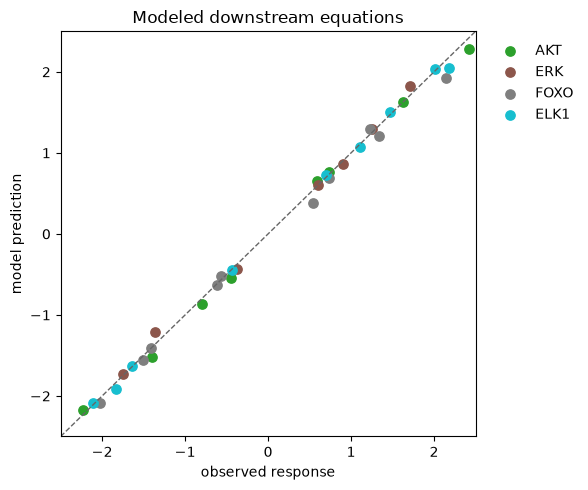

In [10]:
prediction = np.asarray(problem.expr.prediction.value)
fitted_mask = np.asarray(problem.expr.fitted_mask.value).astype(bool)
modeled_vertices = set(edge_table.loc[selected, "target"])

fig, ax = plt.subplots(figsize=(6, 5))
colors = plt.cm.tab10(np.linspace(0, 1, pkn.num_vertices))
fit_summary = []
for vertex_index, vertex in enumerate(pkn.V):
    if vertex not in modeled_vertices:
        continue
    keep = fitted_mask[vertex_index]
    observed = method._values[vertex_index, keep]
    modeled = prediction[vertex_index, keep]
    ax.scatter(
        observed,
        modeled,
        label=vertex,
        color=colors[vertex_index],
        s=45,
    )
    fit_summary.append(
        {
            "protein": vertex,
            "fitted observations": int(keep.sum()),
            "mean absolute error": np.mean(np.abs(observed - modeled)),
        }
    )
limits = [-2.5, 2.5]
ax.plot(limits, limits, "--", color="0.4", linewidth=1)
ax.set(xlabel="observed response", ylabel="model prediction", xlim=limits, ylim=limits)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_title("Modeled downstream equations")
fig.tight_layout()

pd.DataFrame(fit_summary).set_index("protein").round(3)

## Check what was actually fitted

This diagnostic is important with incomplete data. `observed_mask` records available measurements. `fitted_mask` additionally removes perfect-intervention targets and any child equation for which a candidate parent is missing.

That second rule is conservative: it may discard more data than an imputation-based analysis, but it guarantees that a missing predictor is never interpreted as zero.

In [11]:
observed_mask = pd.DataFrame(
    np.asarray(problem.expr.observed_mask.value).astype(bool).T,
    index=method._sample_names,
    columns=pkn.V,
)
used_for_fit = pd.DataFrame(
    fitted_mask.T,
    index=method._sample_names,
    columns=pkn.V,
)

pd.concat(
    {"observed": observed_mask, "used in loss": used_for_fit},
    axis=1,
)

observed                          used in loss                      \
              EGFR   AKT   ERK  FOXO   ELK1         EGFR    AKT    ERK  FOXO   
obs_1         True  True  True  True   True         True   True   True  True   
obs_2         True  True  True  True   True         True   True   True  True   
obs_3         True  True  True  True   True         True   True   True  True   
obs_4         True  True  True  True   True         True   True   True  True   
EGFR_low      True  True  True  True   True        False   True   True  True   
EGFR_high     True  True  True  True   True        False   True   True  True   
AKT_on        True  True  True  True  False         True  False  False  True   
AKT_off       True  True  True  True   True         True  False   True  True   
ERK_on        True  True  True  True   True         True   True  False  True   
ERK_off       True  True  True  True   True         True   True  False  True   

                  
            ELK1  
obs_1       True  
obs_2       True  
obs_3       True  
obs_4       True  
EGFR_low    True  
EGFR_high   True  
AKT_on     False  
AKT_off     True  
ERK_on      True  
ERK_off     True

## Adapting the workflow to your experiment

For a real perturbation panel:

1. use centered continuous measurements, such as log-fold changes relative to an appropriate control;
2. map every feature identifier to the same identifiers used by the PKN;
3. mark only experimentally manipulated vertices as `intervened=True`;
4. represent missing measurements as absent features, `None`, or `NaN`;
5. inspect `fitted_mask`, selected-edge stability, and sensitivity to `lambda_edges` and `min_abs_coefficient` before interpreting the graph.

Optional weights can reflect assay reliability or unequal sample importance:

```python
method = LinearDAGDiscovery(
    vertex_weights={"FOXO": 0.5},       # noisier readout
    sample_weights={"replicate_3": 0.7},
)
```

Weights must be positive. Standardization can be disabled with `standardize_loss=False`, but this is rarely desirable when assays have different units. If zero-coefficient connectors are scientifically intended, set `coefficient_support="structural"`; otherwise keep exact support and choose `min_abs_coefficient` in normalized units for the measurement scale.

## Advanced options and formulation

The sections below are useful when tuning the method or diagnosing a difficult dataset; they are not required for the basic workflow.

### Parameters that change the biological question

| Parameter | Effect |
|---|---|
| `lambda_edges` | Larger values prefer fewer interactions |
| `max_parents` | Limits regulatory complexity at each target |
| `enforce_signs` | Treats PKN activation/inhibition signs as constraints |
| `coefficient_support` | `exact` requires a minimum normalized direct effect; `structural` permits zero-coefficient connectors |
| `min_abs_coefficient` | Minimum normalized coefficient magnitude for selected edges in exact mode |
| `min_commodity_coverage` | Hard minimum fraction of intervention occurrences that must connect to a measured response |
| `lambda_unexplained` | Soft penalty for each intervention occurrence that remains unconnected |
| `flow_epsilon` | Minimum positive flow on each used biological edge |
| `flow_capacity` | Explicit flow upper bound; if omitted, it is the PKN edge count multiplied by `flow_epsilon` |
| `loss="squared"` | Uses a MIQP instead of the default robust L1 MILP |

A useful practical analysis solves a range of edge penalties and minimum-effect thresholds and reports interactions that remain selected. A single optimum should not be interpreted as an uncertainty estimate.

### What does `min_commodity_coverage` mean?

An **intervention commodity** is one intervened vertex in one condition. Thus five conditions with one target each create five commodities; a condition targeting two proteins creates two more. A commodity is covered only when the inferred graph contains a directed route, using at least one selected biological edge, from that intervention to a measured non-intervened response in the same condition.

If there are ten commodities:

- `min_commodity_coverage=0` does not require any intervention to be connected;
- `min_commodity_coverage=0.6` requires at least `ceil(0.6 × 10) = 6` connected commodities;
- `min_commodity_coverage=1` requires all ten and makes the problem infeasible if even one intervention has no eligible route in the PKN.

Coverage is purely **structural**. A covered intervention is not necessarily well predicted, statistically significant, or connected to every measured response. Use `1` only when every perturbation is expected to affect at least one measured downstream node and the PKN should contain that route. For heterogeneous or partly ineffective perturbations, leave the hard minimum at zero or use a smaller fraction. `lambda_unexplained` provides the softer alternative: it encourages more commodities to connect but lets the solver leave unsupported ones unexplained.

### Linear structural equations

For every non-intervened, usable measurement of vertex $v$ in sample $s$, the model predicts

$$
\hat{x}_{v,s} = \alpha_v + \sum_{u\to v} \beta_{u\to v}x_{u,s}.
$$

A selected-edge variable links each coefficient to the discovered graph. The default objective minimizes standardized weighted absolute residuals plus the graph-size penalty:

$$
\sum_{(v,s)\,\mathrm{fitted}}
\frac{w_v w_s}{\sigma_v}\left|x_{v,s}-\hat{x}_{v,s}\right|
+ \lambda_E\sum_e z_e.
$$

The loss scale for a target is computed from usable non-intervened observations with all candidate predictors present; missing predictors are never silently treated as zero. Perfect interventions omit the targeted structural equation in that sample, but the measured intervention value can still explain downstream proteins. In exact support mode, $z_e=1$ additionally implies $|\tilde{\beta}_e|\ge\delta$, where $\tilde{\beta}_e$ is the normalized coefficient and $\delta$ is `min_abs_coefficient`.

### Flow support is a structural certificate

One flow commodity is created for each intervened vertex in each condition. Selected edges must be used by at least one commodity, and flow conservation prevents disconnected selected components. For each commodity, incoming biological edges to vertices perfectly intervened in that condition are disabled, while those same edges remain available to other commodities and to the shared structural equations. With the default `min_commodity_coverage=0`, interventions are allowed to carry no flow; coverage settings control how many must carry a complete intervention-to-response flow. The table below shows which intervention commodities support each inferred interaction.

In [12]:
usage = method.get_edge_usage()
commodity_labels = [
    f"{method._sample_names[sample]}: do({source})"
    for sample, source in zip(method._commodity_samples, method._commodity_sources, strict=True)
]
selected_labels = [
    f'{row.source} → {row.target}'
    for row in edge_table.loc[selected].itertuples()
]

pd.DataFrame(
    usage[selected].astype(int),
    index=selected_labels,
    columns=commodity_labels,
)

,EGFR_low: do(EGFR),EGFR_high: do(EGFR),AKT_on: do(AKT),AKT_off: do(AKT),ERK_on: do(ERK),ERK_off: do(ERK)
EGFR → AKT,1,0,0,0,0,0
EGFR → ERK,0,1,0,0,0,0
AKT → FOXO,0,0,0,1,0,0
ERK → ELK1,0,1,0,0,0,0


A `1` means that the artificial commodity uses that edge. It does **not** measure signaling strength, confidence, molecule abundance, or causal effect size. Coefficients describe linear effect size; flow only certifies intervention-to-response connectivity.

### Computational size

With $E$ candidate edges and $K$ intervention commodities, the default exact-support formulation uses approximately $3E + EK$ binary variables: one shared edge-selection binary, two sign-support binaries per edge, and one flow-use binary per edge and commodity. Structural support removes the two coefficient-sign binaries and is approximately $E + EK$. Optional commodity-coverage variables add $K$ binaries. Boundary edges, standardized weights, and missing-response masks introduce no additional binaries.

The default absolute loss is a MILP and works with open-source mixed-integer solvers. Squared loss is a MIQP and may need a stronger solver on larger problems.

In [13]:
boolean_variables = sum(
    variable.size for variable in result.variables() if variable.attributes["boolean"]
)
integer_variables = sum(
    variable.size for variable in result.variables() if variable.attributes["integer"]
)
continuous_variables = (
    result.size_metrics.num_scalar_variables - boolean_variables - integer_variables
)

pd.Series(
    {
        "continuous": continuous_variables,
        "binary": boolean_variables,
        "general integer": integer_variables,
        "total": result.size_metrics.num_scalar_variables,
    },
    name="CVXPY scalar variables",
)

continuous         165
binary              90
general integer      0
total              255
Name: CVXPY scalar variables, dtype: int64

## Biological interpretation and limitations

The inferred DAG is the smallest flow-supported linear model favored by the chosen penalty. By default, coverage is optional, so this does not mean that every intervention must connect to a response. Exact support further treats a selected edge as a direct fitted effect with a minimum normalized magnitude; structural support instead allows selected zero-coefficient connectors. Neither mode guarantees a nonzero total intervention effect, because downstream paths can cancel.

Its interpretation depends on several assumptions:

- all modeled vertices are observed in at least one sample; fully latent vertices are not estimated;
- coefficients are shared across conditions and effects are additive and linear;
- intervention flags represent perfect interventions;
- unmeasured confounders, feedback dynamics, and context-specific coefficients are not modeled;
- an edge unsupported by the available interventions cannot enter the inferred graph, even if it is biologically real;
- alternative graphs may fit noisy data similarly.

For biological conclusions, repeat the analysis across plausible edge penalties, minimum-effect thresholds, resampled conditions, and reasonable PKN variants. Report stable interactions and competing explanations rather than only one optimized graph.